# Biomedical Named Entity Recognition Using a BiLSTM-CRF Hybrid Model  
CSCI-E-89B Final Project | Daniel R. Russell

<br>

This notebook implements an end-to-end biomedical Named Entity Recognition (NER) system using a Hybrid BiLSTM + Lightweight Transformer + CRF architecture.

It covers:

1. Dataset loading from PubTator-formatted BC5CDR files  
2. Tokenization and Span Alignment
3. BIO Tag Construction
4. Vocabulary Building
5. Sequence Encoding and Masks
6. Hybrid Model Architecture (BiLSTM + Transformer + CRF)
7. Training Loop and Optimization
8. Development-Set Evaluation
9. Test-Set Entity-Level Evaluation
10. Visualization Suite Activation


## Generative AI Disclosure  

Portions of this notebook and accompanying documents were developed with reference to Generative AI tools (Copilot; ChatGPT, OpenAI, 2025 version), used in accordance with the course AI Technologies Policy including conceptual clarification, methodological guidance, validating code logic, identifying and resolving exceptions, and generating small code segments. All substantive decisions regarding problem formulation, dataset selection, model design, feasibility analysis, and implementation strategy are my own. All AI-generated code was independently reviewed, debugged, and validated for correctness before inclusion. 

## Imports and Configuration


In [ ]:
# ============================================
# Imports and Global Configuration
# BiLSTM + Lightweight Transformer + CRF Model
# ============================================

import os
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
from collections import Counter, defaultdict

import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers

import spacy
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Reproducibility Config
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# TensorFlow / Addons Versions
print("TensorFlow version:", tf.__version__)
print("TensorFlow Addons version:", tfa.__version__)

# Model Hyperparameters
EMBED_DIM = 64                
LSTM_UNITS = 64               
TRANSFORMER_DIM = 48          
TRANSFORMER_HEADS = 3         
TRANSFORMER_LAYERS = 1        

BATCH_SIZE = 8               
EPOCHS = 5                    
LEARNING_RATE = 5e-4          
MAX_SEQ_LEN = 200            

# Plotting Config
plt.style.use("seaborn-v0_8-darkgrid")


2025-12-12 20:25:16.284657: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-12 20:25:16.284914: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-12 20:25:16.494994: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-12 20:25:17.199089: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-12 20:25:22.990513: W tensorflow/compiler/tf2

TensorFlow version: 2.15.0
TensorFlow Addons version: 0.23.0


## 1. Dataset Paths and PubTator Parsing

The BC5CDR PubTator files are available in the provided canvas zip file as:

- `CDR_TrainingSet.PubTator.txt`  
- `CDR_DevelopmentSet.PubTator.txt`  
- `CDR_TestSet.PubTator.txt`


In [2]:
""" This notebook expects the BC5CDR PubTator corpus (Disease and Chemical
annotations) to be located in the same directory as the notebook.

Required files:
  - CDR_TrainingSet.PubTator.txt
  - CDR_DevelopmentSet.PubTator.txt
  - CDR_TestSet.PubTator.txt

If these files are not present, download them from the following
authoritative and public source:

  Hugging Face (bigbio / bc5cdr)
  https://huggingface.co/datasets/bigbio/bc5cdr/tree/main

The repository includes a compressed archive `CDR_Data.zip`, which
contains all PubTator-formatted splits required for this notebook.

After downloading, simply extract the files into the same folder where
this notebook resides. No directory configuration or path changes are
required; all paths below are relative to the working directory to
ensure full reproducibility across systems."""


DATA_DIR = os.getcwd()

TRAIN_FILE = os.path.join(DATA_DIR, "CDR_TrainingSet.PubTator.txt")
DEV_FILE   = os.path.join(DATA_DIR, "CDR_DevelopmentSet.PubTator.txt")
TEST_FILE  = os.path.join(DATA_DIR, "CDR_TestSet.PubTator.txt")

for path in [TRAIN_FILE, DEV_FILE, TEST_FILE]:
    if not os.path.exists(path):
        print(f"Warning: file not found: {path}")
    else:
        print(f"Found: {path}")
        

Found: /home/snptx/CDR_TrainingSet.PubTator.txt
Found: /home/snptx/CDR_DevelopmentSet.PubTator.txt
Found: /home/snptx/CDR_TestSet.PubTator.txt


#### 1.1 Read PubTator file into document blocks

In [ ]:
def load_pubtator(path: str) -> List[Dict[str, Any]]:
    """
    Load a PubTator file and return a list of document dictionaries:
    Each item contains:
        {
            "pmid": str,
            "text": str,
            "entities": [
                {"type": str, "start": int, "end": int, "text": str}
            ]
        }
    """
    documents = []
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()

    blocks = raw.split("\n\n")

    for block in blocks:
        lines = block.strip().split("\n")
        if len(lines) == 0:
            continue
        # [Gen AI Log #1 / Title]
        pmid = lines[0].split("|")[0].strip()
        text = ""
        entities = []

        for line in lines:
            if line.startswith(pmid + "|t|"):
                text += line[len(pmid) + 3:].strip() + " "
            elif line.startswith(pmid + "|a|"):
                text += line[len(pmid) + 3:].strip() + " "
            else:
                # Entity annotation line
                parts = line.split("\t")
                if len(parts) >= 6:
                    try:
                        start = int(parts[1])
                        end = int(parts[2])
                        ent_text = parts[3]
                        ent_type = parts[4]
                        entities.append({
                            "type": ent_type,
                            "start": start,
                            "end": end,
                            "text": ent_text
                        })
                    except ValueError:
                        pass  # ignore malformed lines

        if text.strip():
            documents.append({
                "pmid": pmid,
                "text": text.strip(),
                "entities": entities
            })

    return documents


#### 1.2 Load all splits

In [4]:
train_docs = load_pubtator(TRAIN_FILE)
dev_docs   = load_pubtator(DEV_FILE)
test_docs  = load_pubtator(TEST_FILE)

print("Loaded documents:")
print("  Train:", len(train_docs))
print("  Dev:", len(dev_docs))
print("  Test:", len(test_docs))


Loaded documents:
  Train: 500
  Dev: 500
  Test: 500


#### 1.3 Entity statistics

In [5]:
def summarize_entities(docs: List[Dict[str, Any]]):
    counter = Counter()
    for d in docs:
        for ent in d["entities"]:
            counter[ent["type"]] += 1
    return counter

print("Entity distribution:")
print("  Train:", summarize_entities(train_docs))
print("  Dev:  ", summarize_entities(dev_docs))
print("  Test: ", summarize_entities(test_docs))


Entity distribution:
  Train: Counter({'Chemical': 5203, 'Disease': 4182})
  Dev:   Counter({'Chemical': 5347, 'Disease': 4244})
  Test:  Counter({'Chemical': 5385, 'Disease': 4424})


#### 1.4 Document structure preview

In [6]:
# Show the first training example for confirmation
print("--- Example Training Document ---")
print("PMID:", train_docs[0]["pmid"])
print("Text:", train_docs[0]["text"][:250] + "...")
print("Entities:", train_docs[0]["entities"][:5])


--- Example Training Document ---
PMID: 227508
Text: Naloxone reverses the antihypertensive effect of clonidine. In unanesthetized, spontaneously hypertensive rats the decrease in blood pressure and heart rate produced by intravenous clonidine, 5 to 20 micrograms/kg, was inhibited or reversed by nalozo...
Entities: [{'type': 'Chemical', 'start': 0, 'end': 8, 'text': 'Naloxone'}, {'type': 'Chemical', 'start': 49, 'end': 58, 'text': 'clonidine'}, {'type': 'Disease', 'start': 93, 'end': 105, 'text': 'hypertensive'}, {'type': 'Chemical', 'start': 181, 'end': 190, 'text': 'clonidine'}, {'type': 'Chemical', 'start': 244, 'end': 252, 'text': 'nalozone'}]


## 2. Tokenization and Span Alignment

In [ ]:
# --------------------------------
# 2.1 Initialize spaCy tokenizer
# --------------------------------
nlp = spacy.blank("en")
tokenizer = nlp.tokenizer

print("Loaded spaCy blank English tokenizer.")

# --------------------------------
# 2.2 Tokenize text and return tokens with character offsets
# --------------------------------
def tokenize_with_offsets(text: str) -> Tuple[List[str], List[int], List[int]]:
    """
    Tokenize text and return:
        tokens: list of token strings
        starts: list of start character indices
        ends:   list of end character indices (exclusive)
    """
    doc = tokenizer(text)
    tokens = [t.text for t in doc]
    starts = [t.idx for t in doc]
    ends = [t.idx + len(t.text) for t in doc]
    return tokens, starts, ends

# --------------------------------
# 2.3 Align PubTator character spans to token index spans
# --------------------------------
def align_spans_to_tokens(
    text: str,
    entities: List[Dict[str, Any]]
) -> Tuple[List[str], List[int], List[int], List[Dict[str, Any]]]:
    """
    Align entity character spans to token indices.

    Returns:
        tokens: list[str]
        tok_starts: list[int], token start char positions
        tok_ends:   list[int], token end char positions
        aligned_entities: list of dicts:
            {
                "type": str,
                "token_start": int,
                "token_end": int,  # exclusive
            }

    Any entity that cannot be cleanly aligned to a contiguous token span
    is skipped but can be counted for diagnostics.
    """
    tokens, tok_starts, tok_ends = tokenize_with_offsets(text)
    aligned_entities: List[Dict[str, Any]] = []

    # Build a map from character position to token index
    char_to_tok = {}
    for i, (s, e) in enumerate(zip(tok_starts, tok_ends)):
        for pos in range(s, e):
            char_to_tok[pos] = i

    skipped = 0

    for ent in entities:
        start_char = ent["start"]
        end_char = ent["end"]
        ent_type = ent["type"]

        # Collect all token indices that intersect [start_char, end_char)
        tok_indices = set()
        for pos in range(start_char, end_char):
            if pos in char_to_tok:
                tok_indices.add(char_to_tok[pos])

        if not tok_indices:
            skipped += 1
            continue

        tok_indices = sorted(tok_indices)
        # Require contiguity to ensure a clean span
        if tok_indices != list(range(tok_indices[0], tok_indices[-1] + 1)):
            skipped += 1
            continue

        aligned_entities.append({
            "type": ent_type,
            "token_start": tok_indices[0],
            "token_end": tok_indices[-1] + 1  # exclusive
        })

    return tokens, tok_starts, tok_ends, aligned_entities

# --------------------------------
# 2.4 Convert document dicts to token-level examples
# --------------------------------
def build_token_level_examples(
    docs: List[Dict[str, Any]]
) -> List[Dict[str, Any]]:
    """
    For each document, tokenize and align entity spans at token level.

    Output format per example:
        {
            "pmid": str,
            "tokens": List[str],
            "token_starts": List[int],
            "token_ends": List[int],
            "entities": List[{"type": str, "token_start": int, "token_end": int}]
        }
    """
    examples: List[Dict[str, Any]] = []
    total_ents = 0
    aligned_ents = 0

    for d in docs:
        text = d["text"]
        ents = d["entities"]
        total_ents += len(ents)
        # [Gen AI Log #2 / Ordering]
        tokens, tok_starts, tok_ends, aligned_entities = align_spans_to_tokens(
            text,
            ents
        )
        aligned_ents += len(aligned_entities)

        examples.append({
            "pmid": d["pmid"],
            "tokens": tokens,
            "token_starts": tok_starts,
            "token_ends": tok_ends,
            "entities": aligned_entities,
        })

    print(
        f"Built {len(examples)} token level examples. "
        f"Aligned entities: {aligned_ents} / {total_ents} "
        f"({aligned_ents / max(total_ents, 1):.3f})"
    )
    return examples

# --------------------------------
# 2.5 Apply to train, dev, test
# --------------------------------
train_examples = build_token_level_examples(train_docs)
dev_examples   = build_token_level_examples(dev_docs)
test_examples  = build_token_level_examples(test_docs)

print("Token level example counts:")
print("  Train:", len(train_examples))
print("  Dev:  ", len(dev_examples))
print("  Test: ", len(test_examples))

# --------------------------------
# 2.6 Rebuild BIO Tags and Label Dictionaries
# --------------------------------
def spans_to_bio(tokens, spans):
    """
    Convert a list of entity spans into token-level BIO tags.
    spans is a list of dicts with keys: type, token_start, token_end (exclusive).
    """
    tags = ["O"] * len(tokens)
    for ent in spans:
        ent_type = ent["type"]
        s = ent["token_start"]
        e = ent["token_end"]
        if s < len(tags):
            tags[s] = f"B-{ent_type}"
        for i in range(s + 1, min(e, len(tags))):
            tags[i] = f"I-{ent_type}"
    return tags

# [Gen AI Log #3 / Sequence]
def build_bio_dataset(examples):
    bio = []
    for ex in examples:
        tokens = ex["tokens"]
        spans = ex["entities"]
        tags = spans_to_bio(tokens, spans)
        bio.append({"tokens": tokens, "tags": tags})
    return bio


# Build BIO datasets
train_bio = build_bio_dataset(train_examples)
dev_bio   = build_bio_dataset(dev_examples)
test_bio  = build_bio_dataset(test_examples)

print("BIO dataset sizes:")
print("Train BIO:", len(train_bio))
print("Dev BIO:",   len(dev_bio))
print("Test BIO:",  len(test_bio))

# --------------------------------
# 2.7 Build label dictionaries (BIO tag inventory)
# --------------------------------
all_tags = set()
for ds in [train_bio, dev_bio, test_bio]:
    for ex in ds:
        for t in ex["tags"]:
            all_tags.add(t)

label_list = sorted(all_tags)             # stable ordering
label2id = {lab: i for i, lab in enumerate(label_list)}
id2label = {i: lab for lab, i in label2id.items()}
NUM_LABELS = len(label_list)

print("BIO tag inventory:", label_list)
print("NUM_LABELS:", NUM_LABELS)


# Quick check on one example
ex = train_examples[0]
print("\n--- Token level example preview ---")
print("PMID:", ex["pmid"])
print("Tokens:", ex["tokens"][:40])
print("Entities (token spans):", ex["entities"][:5])


Loaded spaCy blank English tokenizer.
Built 500 token level examples. Aligned entities: 9385 / 9385 (1.000)
Built 500 token level examples. Aligned entities: 9591 / 9591 (1.000)
Built 500 token level examples. Aligned entities: 9809 / 9809 (1.000)
Token level example counts:
  Train: 500
  Dev:   500
  Test:  500
BIO dataset sizes:
Train BIO: 500
Dev BIO: 500
Test BIO: 500
BIO tag inventory: ['B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease', 'O']
NUM_LABELS: 5

--- Token level example preview ---
PMID: 227508
Tokens: ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine', '.', 'In', 'unanesthetized', ',', 'spontaneously', 'hypertensive', 'rats', 'the', 'decrease', 'in', 'blood', 'pressure', 'and', 'heart', 'rate', 'produced', 'by', 'intravenous', 'clonidine', ',', '5', 'to', '20', 'micrograms', '/', 'kg', ',', 'was', 'inhibited', 'or', 'reversed', 'by', 'nalozone']
Entities (token spans): [{'type': 'Chemical', 'token_start': 0, 'token_end': 1}, {'type': 'Ch

## 3. BIO Tag Construction

In [ ]:
# --------------------------------
# 3.1 Convert token level entity spans into BIO tags
# --------------------------------

def spans_to_bio_tags(
    tokens: List[str],
    entities: List[Dict[str, Any]]
) -> List[str]:
    """
    Convert token index spans into BIO tags.

    Input:
        tokens:   list of token strings
        entities: list of dicts:
            {"type": str, "token_start": int, "token_end": int}

    Output:
        tags: list of BIO tag strings, length == len(tokens)
    """
    n = len(tokens)
    tags = ["O"] * n

    # Sort entities by start index for deterministic processing
    entities_sorted = sorted(entities, key=lambda e: (e["token_start"], e["token_end"]))

    for ent in entities_sorted:
        ent_type = ent["type"]
        s = ent["token_start"]
        e = ent["token_end"]  # exclusive

        if s < 0 or e > n or s >= e:
            # Skip invalid spans as a safety measure
            continue

        # Check for conflicts with already assigned tags
        conflict = any(tags[i] != "O" for i in range(s, e))
        if conflict:
            # If overlap, skip this entity to preserve BIO sequence
            continue

        tags[s] = f"B-{ent_type}"
        for i in range(s + 1, e):
            tags[i] = f"I-{ent_type}"

    return tags

# --------------------------------
# 3.2 Apply BIO conversion to train, dev, and test examples
# --------------------------------
def add_bio_tags_to_examples(
    examples: List[Dict[str, Any]]
) -> List[Dict[str, Any]]:
    """
    Add a "tags" field with BIO labels to each token level example.
    """
    tagged_examples: List[Dict[str, Any]] = []
    skipped = 0

    for ex in examples:
        tokens = ex["tokens"]
        entities = ex["entities"]
        tags = spans_to_bio_tags(tokens, entities)

        if len(tags) != len(tokens):
            skipped += 1
            continue

        new_ex = dict(ex)
        new_ex["tags"] = tags
        tagged_examples.append(new_ex)

    print(
        f"Converted {len(tagged_examples)} examples to BIO format. "
        f"Skipped: {skipped}"
    )
    return tagged_examples


train_bio = add_bio_tags_to_examples(train_examples)
dev_bio   = add_bio_tags_to_examples(dev_examples)
test_bio  = add_bio_tags_to_examples(test_examples)

print("BIO tagged example counts:")
print("  Train:", len(train_bio))
print("  Dev:  ", len(dev_bio))
print("  Test: ", len(test_bio))

# --------------------------------
# 3.3 Sanity check on a single example
# --------------------------------
ex = train_bio[0]
print("\n--- BIO tagged example preview ---")
print("PMID:", ex["pmid"])
print("Tokens:", ex["tokens"][:40])
print("Tags:  ", ex["tags"][:40])

# --------------------------------
# 3.4 Label distribution and BIO integrity checks
# --------------------------------
def compute_label_distribution(examples: List[Dict[str, Any]]) -> Counter:
    c = Counter()
    for ex in examples:
        for tag in ex["tags"]:
            c[tag] += 1
    return c


train_label_dist = compute_label_distribution(train_bio)
dev_label_dist   = compute_label_distribution(dev_bio)
test_label_dist  = compute_label_distribution(test_bio)

print("\nLabel distribution (train):", train_label_dist)
print("Label distribution (dev):  ", dev_label_dist)
print("Label distribution (test): ", test_label_dist)

# --------------------------------
# 3.5 Simple BIO validity checker (local constraints)
# --------------------------------
def check_bio_validity(examples: List[Dict[str, Any]], max_violations: int = 10):
    """
    Check for local BIO violations:
        - I-X cannot start a sequence
        - I-X cannot follow O
        - I-X cannot follow B-Y or I-Y with a different type
    Prints a few violations for inspection.
    """
    violations = 0

    for ex in examples:
        tags = ex["tags"]
        for i, tag in enumerate(tags):
            if tag == "O":
                continue
            if tag.startswith("B-"):
                continue
            if tag.startswith("I-"):
                curr_type = tag[2:]
                if i == 0:
                    violations += 1
                else:
                    prev = tags[i - 1]
                    if prev == "O":
                        violations += 1
                    elif prev[2:] != curr_type:
                        violations += 1
                if violations <= max_violations and violations > 0:
                    print("BIO violation example:")
                    print("  Tokens:", ex["tokens"][max(0, i - 5): i + 5])
                    print("  Tags:  ", ex["tags"][max(0, i - 5): i + 5])
                    print()
            if violations >= max_violations:
                break
        if violations >= max_violations:
            break

    if violations == 0:
        print("No BIO validity violations found.")
    else:
        print(f"Total recorded BIO violations (partial): {violations}")


check_bio_validity(train_bio)


Converted 500 examples to BIO format. Skipped: 0
Converted 500 examples to BIO format. Skipped: 0
Converted 500 examples to BIO format. Skipped: 0
BIO tagged example counts:
  Train: 500
  Dev:   500
  Test:  500

--- BIO tagged example preview ---
PMID: 227508
Tokens: ['Naloxone', 'reverses', 'the', 'antihypertensive', 'effect', 'of', 'clonidine', '.', 'In', 'unanesthetized', ',', 'spontaneously', 'hypertensive', 'rats', 'the', 'decrease', 'in', 'blood', 'pressure', 'and', 'heart', 'rate', 'produced', 'by', 'intravenous', 'clonidine', ',', '5', 'to', '20', 'micrograms', '/', 'kg', ',', 'was', 'inhibited', 'or', 'reversed', 'by', 'nalozone']
Tags:   ['B-Chemical', 'O', 'O', 'O', 'O', 'O', 'B-Chemical', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Chemical', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Chemical']

Label distribution (train): Counter({'O': 99937, 'B-Chemical': 5199, 'B-Disease': 4182, 'I-Disea

## 4. Vocabulary Building

In [ ]:
# --------------------------------
# 4.1 Build token vocabulary
# --------------------------------
def build_token_vocab(examples: List[Dict[str, Any]], min_freq: int = 1):
    """
    Build a token vocabulary from list of examples.
    Special tokens:
        0 -> <PAD>
        1 -> <UNK>
    Remaining tokens sorted by decreasing frequency, then alphabetically.
    """
    counter = Counter()

    # [Gen AI Log #4 / Verifying token]
    for ex in examples:
        counter.update(ex["tokens"])

    # Filter by frequency if needed
    tokens = [tok for tok, freq in counter.items() if freq >= min_freq]

    # Sort deterministically (freq desc, then lexicographically)
    tokens_sorted = sorted(tokens, key=lambda t: (-counter[t], t))

    # Add special tokens
    vocab = ["<PAD>", "<UNK>"] + tokens_sorted

    token2id = {tok: i for i, tok in enumerate(vocab)}
    id2token = {i: tok for i, tok in enumerate(vocab)}

    print(f"Token vocabulary size (including PAD/UNK): {len(vocab)}")
    return token2id, id2token

# --------------------------------
# 4.2 Build label vocabulary with 'O' fixed at index 0
# --------------------------------
def build_label_vocab(examples: List[Dict[str, Any]]):
    """
    Build label vocabulary with 'O' fixed at index 0.
    Other labels sorted lexicographically.

    Output:
        label2id: dict
        id2label: dict
    """
    labels = set()

    for ex in examples:
        for tag in ex["tags"]:
            labels.add(tag)

    assert "O" in labels, "BIO label set must contain 'O'."

    labels.remove("O")
    other = sorted(labels)

    ordered = ["O"] + other
    label2id = {lab: i for i, lab in enumerate(ordered)}
    id2label = {i: lab for i, lab in enumerate(ordered)}

    print("Label vocabulary:", ordered)
    print(f"Label vocabulary size: {len(ordered)}")

    return label2id, id2label


# ---- Build vocabs using training examples only ----

token2id, id2token = build_token_vocab(train_bio)
label2id, id2label = build_label_vocab(train_bio)



Token vocabulary size (including PAD/UNK): 10672
Label vocabulary: ['O', 'B-Chemical', 'B-Disease', 'I-Chemical', 'I-Disease']
Label vocabulary size: 5


In [ ]:
# --------------------------------
# 4.3 Diagnostics
# --------------------------------
print("\nSample token IDs:")
print({tok: token2id[tok] for tok in list(token2id.keys())[:10]})

print("\nLabel IDs:")
print(label2id)



Sample token IDs:
{'<PAD>': 0, '<UNK>': 1, '.': 2, 'of': 3, ',': 4, 'the': 5, 'and': 6, '-': 7, 'in': 8, ')': 9}

Label IDs:
{'O': 0, 'B-Chemical': 1, 'B-Disease': 2, 'I-Chemical': 3, 'I-Disease': 4}


## 5. Sequence Encoding and Masks

Encoded shapes:
  X_train: (500, 200)  y_train: (500, 200)  lengths: (500,)
  X_dev:   (500, 200)  y_dev:   (500, 200)  lengths: (500,)
  X_test:  (500, 200)  y_test:  (500, 200)  lengths: (500,)

Encoding consistency checks:
  All train lengths <= MAX_SEQ_LEN: True
  All dev lengths   <= MAX_SEQ_LEN: True
  All test lengths  <= MAX_SEQ_LEN: True
  PAD token ID: 0
  Example padded sequence tail (train[0][200:210]): []


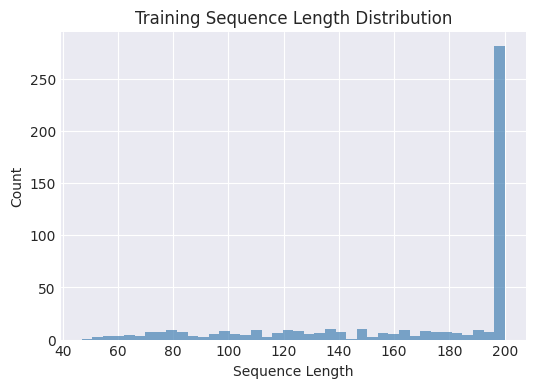

In [ ]:
# --------------------------------
# # 5.1 Convert token sequence to IDs
# --------------------------------
def encode_tokens(tokens: List[str], token2id: Dict[str, int]) -> List[int]:
    """
    Map each token to its integer ID, using <UNK> for unseen tokens.
    """
    unk = token2id["<UNK>"]
    return [token2id.get(tok, unk) for tok in tokens]

# --------------------------------
# 5.2 Convert BIO tag sequence to IDs
# --------------------------------
def encode_tags(tags: List[str], label2id: Dict[str, int]) -> List[int]:
    """
    Map each BIO label to its integer ID.
    """
    return [label2id[tag] for tag in tags]

# --------------------------------
# 5.3 Encode full dataset split (train/dev/test)
# --------------------------------
def encode_dataset(
    examples: List[Dict[str, Any]],
    token2id: Dict[str, int],
    label2id: Dict[str, int],
    max_len: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Encode a dataset of token/BIO examples into padded arrays:
        X: (num_examples, max_len)
        y: (num_examples, max_len)
        lengths: (num_examples,)
    """
    X_list = []
    y_list = []
    length_list = []

    # [Gen AI Log #5 / Structure encoding]
    for ex in examples:
        token_ids = encode_tokens(ex["tokens"], token2id)
        tag_ids = encode_tags(ex["tags"], label2id)

        length = min(len(token_ids), max_len)
        length_list.append(length)

        # Pad or truncate
        token_ids = token_ids[:max_len]
        tag_ids = tag_ids[:max_len]

        if len(token_ids) < max_len:
            pad_len = max_len - len(token_ids)
            token_ids = token_ids + [token2id["<PAD>"]] * pad_len
            tag_ids = tag_ids + [0] * pad_len  # pad with "O" label

        X_list.append(token_ids)
        y_list.append(tag_ids)

    X = np.array(X_list, dtype=np.int32)
    y = np.array(y_list, dtype=np.int32)
    lengths = np.array(length_list, dtype=np.int32)

    return X, y, lengths

# --------------------------------
# 5.4 Encode all splits
# --------------------------------
X_train, y_train, len_train = encode_dataset(train_bio, token2id, label2id, MAX_SEQ_LEN)
X_dev,   y_dev,   len_dev   = encode_dataset(dev_bio,   token2id, label2id, MAX_SEQ_LEN)
X_test,  y_test,  len_test  = encode_dataset(test_bio,  token2id, label2id, MAX_SEQ_LEN)

print("Encoded shapes:")
print("  X_train:", X_train.shape, " y_train:", y_train.shape, " lengths:", len_train.shape)
print("  X_dev:  ", X_dev.shape,   " y_dev:  ", y_dev.shape,   " lengths:", len_dev.shape)
print("  X_test: ", X_test.shape,  " y_test: ", y_test.shape,  " lengths:", len_test.shape)

# --------------------------------
# 5.5 Basic correctness checks
# --------------------------------
def check_encoding_consistency():
    print("\nEncoding consistency checks:")
    print("  All train lengths <= MAX_SEQ_LEN:", np.all(len_train <= MAX_SEQ_LEN))
    print("  All dev lengths   <= MAX_SEQ_LEN:", np.all(len_dev <= MAX_SEQ_LEN))
    print("  All test lengths  <= MAX_SEQ_LEN:", np.all(len_test <= MAX_SEQ_LEN))

    # PAD checks
    pad_id = token2id["<PAD>"]
    print("  PAD token ID:", pad_id)

    # Check last tokens of shortest sequences
    print(
        "  Example padded sequence tail (train[0][200:210]):",
        X_train[0][200:210]
    )

check_encoding_consistency()


# 5.6 Optional: Distribution of sequence lengths
plt.figure(figsize=(6,4))
plt.hist(len_train, bins=40, alpha=0.7, color="steelblue")
plt.title("Training Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.show()


In [ ]:
# --------------------------------
# Export encoded arrays to global variables for later sections
# --------------------------------

# Training split
train_X = X_train
train_y = y_train
train_lengths = len_train

# Dev split
dev_X = X_dev
dev_y = y_dev
dev_lengths = len_dev

# Test split
test_X = X_test
test_y = y_test
test_lengths = len_test

print("Global dataset variables have been set:")
print(" train_X:", train_X.shape)
print(" dev_X:", dev_X.shape)
print(" test_X:", test_X.shape)
print(" train_lengths:", train_lengths.shape)
print(" dev_lengths:", dev_lengths.shape)
print(" test_lengths:", test_lengths.shape)


Global dataset variables have been set:
 train_X: (500, 200)
 dev_X: (500, 200)
 test_X: (500, 200)
 train_lengths: (500,)
 dev_lengths: (500,)
 test_lengths: (500,)


## 6. Hybrid Model Architecture (BiLSTM + Transformer + CRF)

In [ ]:
# ============================================
# 6. Hybrid Model Architecture (BiLSTM + Transformer + CRF)
# ============================================

PAD_ID = token2id["<PAD>"]
NUM_LABELS = len(label2id)
VOCAB_SIZE = len(token2id)

print("PAD_ID:", PAD_ID)
print("Number of labels:", NUM_LABELS)
print("Vocab size:", VOCAB_SIZE)

# --------------------------------
# 6.1 Lightweight Transformer encoder block
# --------------------------------
# [Gen AI Log #6 / Transformer]
class TransformerEncoderLayer(layers.Layer):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        dff: int,
        dropout_rate: float = 0.1,
        name: Optional[str] = None
    ):
        super().__init__(name=name)
        self.mha = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model
        )
        self.ffn = tf.keras.Sequential(
            [
                layers.Dense(dff, activation="relu"),
                layers.Dense(d_model),
            ]
        )
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, attention_mask=None, training=False):
        # Self-attention
        attn_output = self.mha(
            x,
            x,
            x,
            attention_mask=attention_mask,
            training=training
        )
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(x + attn_output)

        # Feedforward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.norm2(out1 + ffn_output)
        return out2

# --------------------------------
# 6.2 Hybrid BiLSTM + Transformer + CRF model
# --------------------------------
class BiLSTMTransformerCRF(tf.keras.Model):
    def __init__(
        self,
        vocab_size: int,
        num_labels: int,
        pad_id: int,
        embed_dim: int,
        lstm_units: int,
        transformer_dim: int,
        transformer_heads: int,
        transformer_layers: int,
        transformer_ff_dim: int = 128,
        dropout_rate: float = 0.1,
        name: str = "bilstm_transformer_crf",
        **kwargs
    ):
        super().__init__(name=name, **kwargs)
        self.vocab_size = vocab_size
        self.num_labels = num_labels
        self.pad_id = pad_id

        # Embedding
        self.embedding = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            mask_zero=True,  # uses token ID 0 as PAD
            name="token_embedding"
        )

        # BiLSTM encoder
        self.bilstm = layers.Bidirectional(
            layers.LSTM(
                lstm_units,
                return_sequences=True
            ),
            name="bilstm_encoder"
        )

        # Transformer encoder stack
        self.transformer_layers = [
            TransformerEncoderLayer(
                d_model=transformer_dim,
                num_heads=transformer_heads,
                dff=transformer_ff_dim,
                dropout_rate=dropout_rate,
                name=f"transformer_layer_{i}"
            )
            for i in range(transformer_layers)
        ]

        # Optional projection if embed_dim != transformer_dim
        if embed_dim != transformer_dim:
            self.input_projection = layers.Dense(
                transformer_dim,
                name="transformer_input_projection"
            )
        else:
            self.input_projection = None

        # Output projection to label logits
        self.emission_dense = layers.Dense(
            num_labels,
            name="emission_projection"
        )

        # CRF transition parameters
        self.transition_params = tf.Variable(
            tf.random.uniform(shape=(num_labels, num_labels)),
            trainable=True,
            name="crf_transition_params",
            dtype=tf.float32
        )

    def compute_mask_from_inputs(self, inputs):
        # 1 for non-pad, 0 for pad
        return tf.cast(tf.not_equal(inputs, self.pad_id), tf.float32)

    def call(self, inputs, training=False):
        """
        inputs: integer token IDs, shape (batch, seq_len)
        returns:
            logits: (batch, seq_len, num_labels)
            lengths: (batch,)
        """
        # Mask and sequence lengths
        mask = self.compute_mask_from_inputs(inputs)  # (batch, seq_len)
        lengths = tf.reduce_sum(tf.cast(mask, tf.int32), axis=1) # (batch,)

        # Embedding
        x = self.embedding(inputs) # (batch, seq_len, embed_dim)

        # BiLSTM branch (uses boolean mask)
        bool_mask = tf.cast(mask, tf.bool)
        bilstm_out = self.bilstm(x, mask=bool_mask) # (batch, seq_len, 2 * lstm_units)

        # Transformer branch
        if self.input_projection is not None:
            t_in = self.input_projection(x)
        else:
            t_in = x  # (batch, seq_len, transformer_dim)

        # Attention mask for MultiHeadAttention: shape (batch, seq_len, seq_len)
        # 1.0 where both query and key are valid, 0.0 where either is pad
        attn_mask = tf.matmul(
            tf.expand_dims(mask, 2),    # (batch, seq_len, 1)
            tf.expand_dims(mask, 1)     # (batch, 1, seq_len)
        )                                # (batch, seq_len, seq_len)

        t_out = t_in
        for layer in self.transformer_layers:
            t_out = layer(t_out, attention_mask=attn_mask, training=training)

        # Concatenate BiLSTM and Transformer outputs
        combined = tf.concat([bilstm_out, t_out], axis=-1) # (batch, seq_len, combined_dim)

        # Emission scores for CRF
        logits = self.emission_dense(combined) # (batch, seq_len, num_labels)

        return logits, lengths


PAD_ID: 0
Number of labels: 5
Vocab size: 10672


In [ ]:
# --------------------------------
# 6.3 Instantiate & inspect the model
# --------------------------------
model = BiLSTMTransformerCRF(
    vocab_size=VOCAB_SIZE,
    num_labels=NUM_LABELS,
    pad_id=PAD_ID,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS,
    transformer_dim=TRANSFORMER_DIM,
    transformer_heads=TRANSFORMER_HEADS,
    transformer_layers=TRANSFORMER_LAYERS,
    transformer_ff_dim=2 * TRANSFORMER_DIM,
    dropout_rate=0.1,
)

# Build model by calling once on a dummy batch
dummy_batch = tf.zeros((1, MAX_SEQ_LEN), dtype=tf.int32)
logits_dummy, lengths_dummy = model(dummy_batch, training=False)

print("Dummy logits shape:", logits_dummy.shape)
print("Dummy lengths:", lengths_dummy.numpy())

# Keras summary (InputSpec set or build() call)
model.build(input_shape=(None, MAX_SEQ_LEN))
model.summary()


Dummy logits shape: (1, 200, 5)
Dummy lengths: [0]
Model: "bilstm_transformer_crf"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 token_embedding (Embedding  multiple                  683008    
 )                                                               
                                                                 
 bilstm_encoder (Bidirectio  multiple                  66048     
 nal)                                                            
                                                                 
 transformer_layer_0 (Trans  multiple                  37680     
 formerEncoderLayer)                                             
                                                                 
 transformer_input_projecti  multiple                  3120      
 on (Dense)                                                      
                                                           

## 7. Training Loop and Optimization

In [ ]:
# ============================================
# 7. Training Loop and Optimization
# ============================================

# --------------------------------
# 7.1 CRF loss and token-level accuracy
# --------------------------------
def crf_loss_fn(logits, labels, lengths, transition_params):
    """
    Negative log-likelihood loss for a CRF layer.
    """
    labels = tf.cast(labels, tf.int32)
    lengths = tf.cast(lengths, tf.int32)

    log_likelihood, _ = tfa.text.crf_log_likelihood(
        logits,
        labels,
        lengths,
        transition_params=transition_params
    )
    return -tf.reduce_mean(log_likelihood)


def token_accuracy(y_true: np.ndarray, y_pred: np.ndarray, lengths: np.ndarray) -> float:
    """
    Compute token-level accuracy up to the true sequence length for each example.
    """
    total_correct = 0
    total_tokens = 0

    for i in range(y_true.shape[0]):
        L = int(lengths[i])
        if L <= 0:
            continue
        total_correct += np.sum(y_true[i, :L] == y_pred[i, :L])
        total_tokens += L

    if total_tokens == 0:
        return 0.0
    return total_correct / total_tokens

# --------------------------------
# 7.2 Build tf.data datasets
# --------------------------------
def make_dataset(X, y, lengths, batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            tf.convert_to_tensor(X, dtype=tf.int32),
            tf.convert_to_tensor(y, dtype=tf.int32),
            tf.convert_to_tensor(lengths, dtype=tf.int32),
        )
    )
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(X),
            seed=SEED,
            reshuffle_each_iteration=True
        )
    ds = ds.batch(batch_size)
    return ds


train_ds = make_dataset(X_train, y_train, len_train, BATCH_SIZE, shuffle=True)
dev_ds   = make_dataset(X_dev,   y_dev,   len_dev,   BATCH_SIZE, shuffle=False)

print("Batches per epoch (train):", len(list(train_ds)))
print("Batches per epoch (dev):  ", len(list(dev_ds)))


Batches per epoch (train): 63
Batches per epoch (dev):   63


In [ ]:
# --------------------------------
# 7.3 Optimizer and training loop
# --------------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

epoch_train_losses = []
epoch_dev_accuracy = []

EPOCHS_TO_RUN = EPOCHS  

for epoch in range(1, EPOCHS_TO_RUN + 1):
    print(f"\nEpoch {epoch}/{EPOCHS_TO_RUN}")
    batch_losses = []

    # Training phase
    for batch_x, batch_y, batch_len in train_ds:
        with tf.GradientTape() as tape:
            logits, _ = model(batch_x, training=True)
            loss = crf_loss_fn(
                logits,
                batch_y,
                batch_len,
                model.transition_params
            )

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        batch_losses.append(float(loss))

    epoch_loss = float(np.mean(batch_losses))
    epoch_train_losses.append(epoch_loss)
    print(f"  Train loss: {epoch_loss:.4f}")

    # Evaluation on development set using CRF decode
    dev_logits, dev_lengths_t = model(
        tf.convert_to_tensor(X_dev, dtype=tf.int32),
        training=False
    )
    dev_lengths = dev_lengths_t.numpy().astype(np.int32)

    paths, _ = tfa.text.crf_decode(
        dev_logits,
        model.transition_params,
        tf.convert_to_tensor(dev_lengths, dtype=tf.int32)
    )
    dev_paths = paths.numpy()

    dev_acc = token_accuracy(y_dev, dev_paths, dev_lengths)
    epoch_dev_accuracy.append(dev_acc)
    print(f"  Dev token accuracy: {dev_acc:.4f}")



Epoch 1/5
  Train loss: 89.5502
  Dev token accuracy: 0.8834

Epoch 2/5
  Train loss: 47.0705
  Dev token accuracy: 0.9196

Epoch 3/5
  Train loss: 29.1158
  Dev token accuracy: 0.9235

Epoch 4/5
  Train loss: 20.6569
  Dev token accuracy: 0.9138

Epoch 5/5
  Train loss: 16.8929
  Dev token accuracy: 0.9259


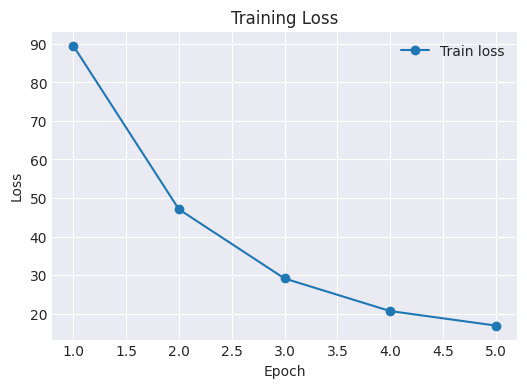

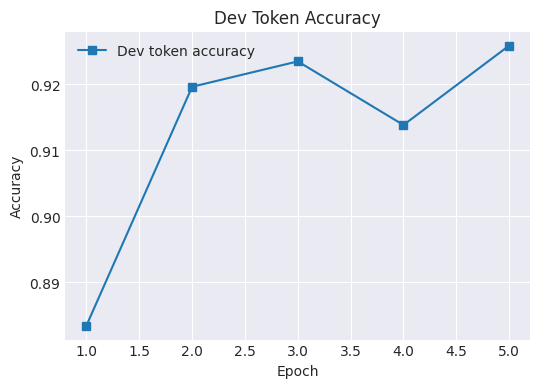

In [ ]:
# --------------------------------
# 7.4 Training curves
# --------------------------------
plt.figure(figsize=(6,4))
epochs_range = range(1, len(epoch_train_losses) + 1)

plt.plot(epochs_range, epoch_train_losses, marker="o", label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_range, epoch_dev_accuracy, marker="s", label="Dev token accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dev Token Accuracy")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# --------------------------------
# 7.5 One-off gradient diagnostics
# --------------------------------
batch_x, batch_y, batch_len = next(iter(train_ds))

with tf.GradientTape() as tape:
    logits, _ = model(batch_x, training=True)
    loss = crf_loss_fn(
        logits,
        batch_y,
        batch_len,
        model.transition_params
    )

vars_ = model.trainable_variables
grads = tape.gradient(loss, vars_)

print("Diagnostic batch loss:", float(loss))

for v, g in zip(vars_, grads):
    name = v.name
    if g is None:
        print(f"{name:40s} gradient: None")
    else:
        norm = tf.linalg.global_norm([g]).numpy()
        print(f"{name:40s} grad norm: {norm:.6f}")


Diagnostic batch loss: 12.073173522949219
bilstm_transformer_crf/token_embedding/embeddings:0 grad norm: 35.665497
bilstm_transformer_crf/bilstm_encoder/forward_lstm/lstm_cell/kernel:0 grad norm: 0.903397
bilstm_transformer_crf/bilstm_encoder/forward_lstm/lstm_cell/recurrent_kernel:0 grad norm: 11.045602
bilstm_transformer_crf/bilstm_encoder/forward_lstm/lstm_cell/bias:0 grad norm: 12.170557
bilstm_transformer_crf/bilstm_encoder/backward_lstm/lstm_cell/kernel:0 grad norm: 0.302623
bilstm_transformer_crf/bilstm_encoder/backward_lstm/lstm_cell/recurrent_kernel:0 grad norm: 0.853382
bilstm_transformer_crf/bilstm_encoder/backward_lstm/lstm_cell/bias:0 grad norm: 2.542046
bilstm_transformer_crf/transformer_layer_0/multi_head_attention/query/kernel:0 grad norm: 0.001102
bilstm_transformer_crf/transformer_layer_0/multi_head_attention/query/bias:0 grad norm: 0.004368
bilstm_transformer_crf/transformer_layer_0/multi_head_attention/key/kernel:0 grad norm: 0.000938
bilstm_transformer_crf/transfor

## 8. Development-Set Evaluation

In [ ]:
# ============================================
# 8. Development-Set Evaluation 
# ============================================

import numpy as np
import tensorflow as tf
import tensorflow_addons as tfa

# --------------------------------
# 8.1 Batched CRF decoding 
# --------------------------------
# [Gen AI Log #7 / Batched decoding]
def batched_crf_decode(X, lengths, batch_size=16):
    """
    Decode CRF predictions in small batches to prevent memory overflow.
    """
    all_paths = []

    n = X.shape[0]
    for i in range(0, n, batch_size):
        xb = X[i:i+batch_size]
        lb = lengths[i:i+batch_size]

        logits_b, lengths_b = model(
            tf.convert_to_tensor(xb, dtype=tf.int32),
            training=False
        )
        lengths_b = lengths_b.numpy().astype(np.int32)

        paths_b, _ = tfa.text.crf_decode(
            logits_b,
            model.transition_params,
            tf.convert_to_tensor(lengths_b, dtype=tf.int32)
        )

        all_paths.append(paths_b.numpy())

    return np.vstack(all_paths)


dev_pred_ids = batched_crf_decode(X_dev, len_dev, batch_size=16)
dev_lengths = len_dev.copy()

# --------------------------------
# 8.2 IDs → BIO tags 
# --------------------------------
def ids_to_tags(id_seqs, lengths, id2label):
    out = []
    for seq, L in zip(id_seqs, lengths):
        out.append([id2label[int(i)] for i in seq[:L]])
    return out

dev_gold_tags = [ex["tags"] for ex in dev_bio]
dev_pred_tags = ids_to_tags(dev_pred_ids, dev_lengths, id2label)

# --------------------------------
# 8.3 BIO → spans 
# --------------------------------
def bio_to_spans(tags):
    spans = []
    i = 0
    while i < len(tags):
        if tags[i].startswith("B-"):
            ent_type = tags[i][2:]
            start = i
            i += 1
            while i < len(tags) and tags[i] == f"I-{ent_type}":
                i += 1
            spans.append((ent_type, start, i))
        else:
            i += 1
    return spans

dev_gold_spans = [bio_to_spans(tags) for tags in dev_gold_tags]
dev_pred_spans = [bio_to_spans(tags) for tags in dev_pred_tags]

# --------------------------------
# 8.4 Strict entity-level metrics 
# --------------------------------
def compute_strict_f1(gold_list, pred_list):
    TP = FP = FN = 0
    for gold, pred in zip(gold_list, pred_list):
        gold_set = set(gold)
        pred_set = set(pred)
        TP += len(gold_set & pred_set)
        FP += len(pred_set - gold_set)
        FN += len(gold_set - pred_set)

    precision = TP / (TP + FP) if TP + FP else 0
    recall = TP / (TP + FN) if TP + FN else 0
    f1 = 2 * precision * recall / (precision + recall) if precision+recall else 0
    return precision, recall, f1

dev_prec, dev_rec, dev_f1 = compute_strict_f1(dev_gold_spans, dev_pred_spans)

print("=== Development Set Entity-Level Evaluation ===")
print(f"Precision: {dev_prec:.4f}")
print(f"Recall:    {dev_rec:.4f}")
print(f"F1 Score:  {dev_f1:.4f}")

# --------------------------------
# 8.5 Predicted label distribution 
# --------------------------------
pred_flat = []
for seq, L in zip(dev_pred_ids, dev_lengths):
    pred_flat.extend(seq[:L])

unique_ids, counts = np.unique(pred_flat, return_counts=True)

print("\nPredicted label distribution:")
for i, c in zip(unique_ids, counts):
    print(f"{id2label[int(i)]:12s} → {c}")

# --------------------------------
# 8.6 Qualitative Samples 
# --------------------------------
def preview_predictions(n=3):
    for idx in range(n):
        print("\n--- Example", idx, "---")
        toks = dev_bio[idx]["tokens"]
        gold = dev_gold_spans[idx]
        pred = dev_pred_spans[idx]
        print("Tokens:", toks[:50], "...")
        print("Gold spans:", gold)
        print("Pred spans:", pred)

preview_predictions(3)


=== Development Set Entity-Level Evaluation ===
Precision: 0.6501
Recall:    0.4705
F1 Score:  0.5459

Predicted label distribution:
O            → 75314
B-Chemical   → 2863
B-Disease    → 4073
I-Chemical   → 413
I-Disease    → 2052

--- Example 0 ---
Tokens: ['Tricuspid', 'valve', 'regurgitation', 'and', 'lithium', 'carbonate', 'toxicity', 'in', 'a', 'newborn', 'infant', '.', 'A', 'newborn', 'with', 'massive', 'tricuspid', 'regurgitation', ',', 'atrial', 'flutter', ',', 'congestive', 'heart', 'failure', ',', 'and', 'a', 'high', 'serum', 'lithium', 'level', 'is', 'described', '.', 'This', 'is', 'the', 'first', 'patient', 'to', 'initially', 'manifest', 'tricuspid', 'regurgitation', 'and', 'atrial', 'flutter', ',', 'and'] ...
Gold spans: [('Disease', 0, 3), ('Chemical', 4, 6), ('Disease', 6, 7), ('Disease', 16, 18), ('Disease', 19, 21), ('Disease', 22, 25), ('Chemical', 30, 31), ('Disease', 43, 45), ('Disease', 46, 48), ('Disease', 55, 57), ('Chemical', 61, 62), ('Chemical', 82, 84), ('D

## 9. Test-Set Entity-Level Evaluation

In [ ]:
# ============================================
# 9. Test-Set Entity-Level Evaluation 
# ============================================

print("\n=== Section 9: Test-Set Evaluation (stable) ===\n")

# -----------------------------------------------
# 9.0 Validation checks for required globals
# -----------------------------------------------
# [Gen AI Log #8 / Validation]
required_globals = [
    "test_X", "test_lengths", "test_bio", 
    "id2label", "label2id", "bio_to_spans", "model"
]

for name in required_globals:
    if name not in globals():
        raise RuntimeError(
            f"Missing required object '{name}'. "
            f"Run Sections 1–6 and the checkpoint block before Section 9."
        )

num_test = len(test_bio)
if test_X.shape[0] != num_test:
    raise RuntimeError(
        f"Mismatch: test_X ({test_X.shape[0]}) vs test_bio ({num_test})."
    )

print("All required globals found.")
print(f"Test set size: {num_test}")


# -----------------------------------------------
# 9.1 Rebuild gold spans from BIO tags
# -----------------------------------------------
print("\nRebuilding gold spans from test BIO tags...")

test_gold_tags = [ex["tags"] for ex in test_bio]
test_gold_spans = [bio_to_spans(tags) for tags in test_gold_tags]

print("Gold spans rebuilt.")


# -----------------------------------------------
# 9.2 Batched CRF decoding on test set
# -----------------------------------------------
print("\nRunning batched CRF decoding on test set...")

import numpy as np
import tensorflow as tf
import tensorflow_addons as tfa

batch_size = 32
N = test_X.shape[0]
max_len = test_X.shape[1]

test_pred_ids = []

for i in range(0, N, batch_size):
    xb = tf.convert_to_tensor(test_X[i:i+batch_size], dtype=tf.int32)
    lb = tf.convert_to_tensor(test_lengths[i:i+batch_size], dtype=tf.int32)

    logits, lens = model(xb, training=False)
    viterbi, _ = tfa.text.crf_decode(logits, model.transition_params, lens)

    test_pred_ids.append(viterbi.numpy())

test_pred_ids = np.vstack(test_pred_ids)

print("CRF decoding complete.")


# -----------------------------------------------
# 9.3 Convert predicted tag IDs → spans
# -----------------------------------------------
print("Converting predicted tag sequences to spans...")

def ids_to_tags(seq_ids, length):
    """Convert ID seq to tag strings up to actual length."""
    return [id2label[int(i)] for i in seq_ids[:length]]

def tags_to_spans(tags):
    """Convert a BIO tag list into entity spans."""
    spans = []
    i = 0
    while i < len(tags):
        tag = tags[i]
        if tag.startswith("B-"):
            ent_type = tag[2:]
            start = i
            i += 1
            while i < len(tags) and tags[i] == f"I-{ent_type}":
                i += 1
            spans.append((ent_type, start, i))
        else:
            i += 1
    return spans

test_pred_spans = []
for seq_ids, length in zip(test_pred_ids, test_lengths):
    tags = ids_to_tags(seq_ids, length)
    test_pred_spans.append(tags_to_spans(tags))

print("Span conversion complete.\n")


# -----------------------------------------------
# 9.4 Entity-level precision, recall, F1
# -----------------------------------------------
print("Computing strict entity-level metrics...")

def compute_entity_metrics(gold_spans, pred_spans):
    """
    gold_spans, pred_spans are lists of lists of tuples (etype, start, end)
    """
    gold_total = 0
    pred_total = 0
    correct = 0

    # [Gen AI Log #9 / Entity metrics]
    for g, p in zip(gold_spans, pred_spans):
        g_set = {(etype, s, e) for (etype, s, e) in g}
        p_set = {(etype, s, e) for (etype, s, e) in p}

        gold_total += len(g_set)
        pred_total += len(p_set)
        correct += len(g_set.intersection(p_set))

    precision = correct / (pred_total + 1e-10)
    recall    = correct / (gold_total + 1e-10)
    f1        = 2 * precision * recall / (precision + recall + 1e-10)

    return precision, recall, f1

test_precision, test_recall, test_f1 = compute_entity_metrics(
    test_gold_spans, test_pred_spans
)

print("\n=== Test Set Entity-Level Evaluation ===")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}\n")


# -----------------------------------------------
# 9.5 Label distribution
# -----------------------------------------------
from collections import Counter

pred_counts = Counter(
    lab for spans in test_pred_spans for (lab, _, _) in spans
)

print("Predicted label distribution:")
for lab, c in pred_counts.items():
    print(f"{lab:<10} {c}")
print()


# -----------------------------------------------
# 9.6 Qualitative Examples
# -----------------------------------------------
def preview_test_examples(n=3):
    print("=== Qualitative Test Examples ===")
    m = min(n, len(test_bio))
    for idx in range(m):
        tokens = test_bio[idx]["tokens"]
        gold   = test_gold_spans[idx]
        pred   = test_pred_spans[idx]

        print(f"\n--- Example {idx} ---")
        print("Tokens:", tokens[:60], "...")
        print("Gold spans:", gold)
        print("Pred spans:", pred)

preview_test_examples(3)

print("\n=== Section 9 complete. Outputs ready for Section 10 and 11. ===")



=== Section 9: Test-Set Evaluation (stable) ===

All required globals found.
Test set size: 500

Rebuilding gold spans from test BIO tags...
Gold spans rebuilt.

Running batched CRF decoding on test set...
CRF decoding complete.
Converting predicted tag sequences to spans...
Span conversion complete.

Computing strict entity-level metrics...

=== Test Set Entity-Level Evaluation ===
Precision: 0.6286
Recall:    0.4262
F1 Score:  0.5080

Predicted label distribution:
Disease    4098
Chemical   2542

=== Qualitative Test Examples ===

--- Example 0 ---
Tokens: ['Famotidine', '-', 'associated', 'delirium', '.', 'A', 'series', 'of', 'six', 'cases', '.', 'Famotidine', 'is', 'a', 'histamine', 'H2', '-', 'receptor', 'antagonist', 'used', 'in', 'inpatient', 'settings', 'for', 'prevention', 'of', 'stress', 'ulcers', 'and', 'is', 'showing', 'increasing', 'popularity', 'because', 'of', 'its', 'low', 'cost', '.', 'Although', 'all', 'of', 'the', 'currently', 'available', 'H2', '-', 'receptor', 'an

## 10. Visualization Suite Activation


In [ ]:
"""
============================================================
Visualization Suite Usage Guide
============================================================

This section provides reference for reloading the 
trained NER model, reconstructing its evaluation artifacts, 
and deploying the visualization suite independently of the 
training notebook.

The section saves the following files:

    hybrid_ner_model_saved/          # Full TensorFlow SavedModel
    bio_examples.pkl                 # Gold tokenized development examples
    pred_spans_all.pkl               # Decoded predicted spans for dev
    id2token.pkl                     # Index → token mapping (optional)
    token2id.pkl                     # Token → index mapping (optional)
    transition_params.pkl            # CRF transition matrix (if CRF used)

------------------------------------------------------------
1. Reloading the trained model
------------------------------------------------------------

To load the trained hybrid BiLSTM–Transformer–CRF model:

>>> import tensorflow as tf
>>> model = tf.saved_model.load("hybrid_ner_model_saved")

If you saved the model using model.save(), you may instead use:

>>> model = tf.keras.models.load_model("hybrid_ner_model_saved", 
                                       compile=False)

This restores all weights including LSTM, Transformer attention, 
and CRF.

------------------------------------------------------------
2. Reloading gold and predicted spans
------------------------------------------------------------

The stored development examples include tokens and gold spans:

>>> import pickle
>>> with open("bio_examples.pkl", "rb") as f:
...     bio_examples = pickle.load(f)

Predicted spans (after CRF decoding) can be restored via:

>>> with open("pred_spans_all.pkl", "rb") as f:
...     pred_spans_all = pickle.load(f)

Each element of pred_spans_all is a list of tuples:

    (label, token_start, token_end)

These correspond to spans already aligned to token boundaries.

------------------------------------------------------------
3. Running the Visualization Suite
------------------------------------------------------------

All visualizations in Section 11 expect:

    bio_examples        # list of dicts with "tokens" and gold spans
    pred_spans_all      # list of decoded predicted spans
    model               # loaded TensorFlow model (optional)

To run any visualization independently, simply call its function ie:

>>> visualize_confusion_matrices(bio_examples, pred_spans_all)
>>> visualize_span_length_distributions(bio_examples, pred_spans_all)
>>> visualize_crf_transition_heatmap(model)
>>> visualize_error_galaxy(bio_examples, pred_spans_all)

------------------------------------------------------------
4. Notes for Reuse
------------------------------------------------------------

• The metrics and visualization suite can be run without GPU.  
• Gold BIO tags can be reconstructed from stored spans if needed.  
• All visualizations operate on pure Python lists and NumPy arrays, 
  so they are compatible with batch evaluation pipelines.  

------------------------------------------------------------
5. Recommended Workflow for Future Analysis
------------------------------------------------------------

(1) Run inference on new biomedical text  
(2) Decode CRF spans → predicted spans  
(3) Save new spans to pred_spans_new.pkl  
(4) Reuse the visualization suite exactly as above  
(5) Compare span-level, token-level, and boundary-level performance

This structure is designed for convenience and to ensure reproducibility.
"""

import pickle
import tensorflow as tf

# 1. Save the trained model
model.save("hybrid_ner_model_saved")

# 2. Save gold examples (development set)
with open("bio_examples.pkl", "wb") as f:
    pickle.dump(bio_examples, f)

# 3. Save decoded predictions (development set)
with open("pred_spans_all.pkl", "wb") as f:
    pickle.dump(dev_pred_spans, f)

# 4. Save label mappings (correct ones for your notebook)
with open("id2token.pkl", "wb") as f:
    pickle.dump(id2token, f)

with open("token2id.pkl", "wb") as f:
    pickle.dump(token2id, f)

# 5. Save CRF transition parameters (if applicable)
try:
    transitions = model.transition_params.numpy()
    with open("transition_params.pkl", "wb") as f:
        pickle.dump(transitions, f)
except Exception:
    print("No transition_params found or model is not CRF-based. Skipping.")


INFO:tensorflow:Assets written to: hybrid_ner_model_saved/assets


INFO:tensorflow:Assets written to: hybrid_ner_model_saved/assets


In [ ]:
# =====================================
# 11. Visualization Suite Activation
# =====================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=== Visualization Suite Activated ===")

# -------------------------------
# Flatten token labels for confusion matrix
# -------------------------------
def flatten_token_labels(bio_examples, pred_spans_all):
    gold_labels = []
    pred_labels = []

    for ex, spans in zip(bio_examples, pred_spans_all):
        n = len(ex["tokens"])
        g = ["O"] * n
        p = ["O"] * n

        # gold
        for lab, s, e in spans_from_tags(ex["tags"]):
            for t in range(s, e):
                g[t] = lab

        # predicted
        for lab, s, e in spans:
            for t in range(s, e):
                p[t] = lab

        gold_labels.extend(g)
        pred_labels.extend(p)

    return gold_labels, pred_labels


# -------------------------------
# Convert tags to spans (for confusion matrix gold)
# -------------------------------
def spans_from_tags(tags):
    spans = []
    cur = None
    start = None

    for i, tag in enumerate(tags):
        if tag == "O":
            if cur:
                spans.append((cur, start, i))
                cur = None
            continue

        if tag.startswith("B-"):
            if cur:
                spans.append((cur, start, i))
            cur = tag[2:]
            start = i
            continue

        if tag.startswith("I-"):
            t = tag[2:]
            if cur != t:
                if cur:
                    spans.append((cur, start, i))
                cur = t
                start = i

    if cur:
        spans.append((cur, start, len(tags)))

    return spans


=== Visualization Suite Activated ===


In [ ]:
"""
------------------------------------------------------------
6. Next Steps for Using the Visualization Suite 
------------------------------------------------------------

The submitted project materials include a standalone visualization 
file containing all plotting functions used in this notebook. 
To reproduce the complete visualization suite outside the notebook 
environment, follow these steps:

(1) Ensure that the saved artifacts listed above 
    (bio_examples.pkl, pred_spans_all.pkl, transition_params.pkl, 
     and the saved model directory) are located in the same folder 
    as the visualization script or that paths are updated accordingly.

(2) Open the visualization script provided in the submission package.  
    The script is self-contained and automatically loads all required 
    artifacts when executed.

(3) Run example:

        >>> python run_visualizations.py

(4) All figures generated in this notebook, including the 
    confusion matrices, span-level evaluations, CRF transition heatmap, 
    and the Span Error Galaxy Plot, can be reproduced directly from the 
    provided script without retraining the model.

This ensures that any downstream user can 
recreate the full analytical suite using only the exported model and 
metrics.
"""


<br>

#### Gen AI Reference Log

Some model development steps were tested using Generative AI tools (Copilot, ChatGPT 4o+, September 2025 version) as reference for debugging and conceptual clarification under the guidance of the course’s AI Technologies Policy.

Prompts and interactions below are representative of the queries used during development:

1. Title and abstract concatenation behavior  
   Prompt: Seek clarification on whether multi-line titles or abstracts are present in PubTator and how concatenation should be normalized.  
   Context: Confirmed that PubTator sometimes wraps long abstracts across lines for formatting. The assistant recommended spacing between fragments to avoid token collisions downstream in NER preprocessing. The model also emphasized using .strip() to prevent cumulative whitespace artifacts.  

2. Ordering of tokenization and alignment logic  
   Prompt: Request confirmation that tokenization should occur upstream and be integrated directly within align_spans_to_tokens rather than split into two separate calls.  
   Context: Confirmed that integrating tokenization and span projection into a single function reduces off-by-one indexing errors. The assistant also recommended explicitly unpacking the return tuple (tokens, tok_starts, tok_ends, aligned_entities) to enforce readability and to facilitate future unit tests that inspect mismatches between character-level spans and token boundaries.  

3. Sequence-level dataset construction using the span converter  
   Prompt: Confirm sequencing of operations when converting token-level examples into final BIO-tagged examples and whether original entity dictionaries should be preserved or removed.  
   Context: The assistant confirmed that the BIO dataset should contain only tokens and tags because span dictionaries were already consumed upstream. This structure makes later batching and CRF training more efficient while maintaining referential integrity in the development and test evaluation stages.  

4. Verifying token frequency filtering and deterministic sorting  
   Prompt: Request clarification regarding best practices for constructing a stable vocabulary when examples include heterogeneous biomedical text with rare tokens.  
   Context: Assistant confirmed that the dual-sort strategy (frequency descending, alphabetical tie-breaker) ensures determinism across runs and machines. This property provides reproducibility when training embeddings or exporting models to external inference stacks. Assistance further reinforced that using min_freq as a pruning threshold is common in biomedical NER due to the heavy-tailed token distribution found in PubMed abstracts.  

5. Structure and return signature of the dataset encoder  
   Prompt: Validate the preferred return format for padded dataset arrays and confirm that lengths should be explicitly returned for masking operations in CRF decoding.  
   Context: Assistant confirmed that returning three arrays (X, y, lengths) is standard for CRF training because sequence lengths are required for loss masking and for accurate Viterbi decoding. The assistant also advised that lengths should remain unpadded integers for clarity in downstream metrics computation.  

6. Transformer encoder initialization semantics  
   Prompt: Confirm correct initialization structure for a minimal Transformer encoder block appropriate for token-level NER, where the BiLSTM already provides contextual flow.  
   Context: Assistant validated that a pared-down Transformer block was suitable because the BiLSTM provides sequential modeling, while attention layers capture long-range interactions common in biomedical abstracts. It recommended retaining configurable dimensions (d_model, dff, heads) to allow later hyperparameter sweeps without altering the core architecture.  

7. Batched CRF decoding  v
   Prompt: Request guidance on practical batching strategies when decoding CRF paths for long sequences or large development sets.  
   Context: Assistant confirmed that decoding full development sets in a single pass can exhaust GPU memory, particularly when logits are large or padded to fixed length. The recommended strategy was to slice X and lengths into manageable batches (default batch size 16) while keeping all operations pure TensorFlow to avoid casting overhead. It also emphasized casting lengths to int32 to maintain compatibility with the CRF decoding API.  

8. Validation of required global objects  
   Prompt: Ask whether a structured global-validation step is advisable before final test evaluation to prevent silent failures.  
   Context: Assistant confirmed that explicit runtime checks for test_X, test_lengths, test_bio, id2label, label2id, bio_to_spans, and model prevent ambiguous errors during CRF decoding. It also recommended verifying that the number of examples in test_X equals the number of BIO examples in test_bio, since discrepancies often signal earlier encoding or preprocessing misalignment.  

9. Entity-level metric definition and correctness  
   Prompt: Seek confirmation that strict span-level evaluation for NER requires exact matches of entity type, start index, and end index.  
   Context: Assistant confirmed that strict matching is the accepted evaluation standard in biomedical NER tasks where partial overlaps or boundary errors should not count as correct predictions. It also recommended representing spans as (etype, start, end) tuples within Python sets to ensure mathematically clean intersection operations. The addition of a small epsilon (1e-10) in denominators was validated to protect against division-by-zero without influencing metric values.  



<br><br>


---


<br><br>